<a href="https://colab.research.google.com/github/dherreraal/data_structures/blob/main/Clase_06/06_ED_Pilas_Multiples_Listas_Dobles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colas con Nodos, Listas Dobles y Múltiples Pilas
### Universidad Nacional de Colombia
#### **Profesor:** David Alberto Herrera Alvarez  
#### **Curso:** Estructuras de Datos
---

## Índice de Contenido
1. Colas usando Listas Enlazadas (Linked Queues)
2. Listas Doblemente Enlazadas (Doubly Linked Lists)
   - 2.1 Colas de Doble Extremo (Deques)
   - 2.2 Costo de Memoria (Overhead) en Nodos Dobles
3. Listas Enlazadas Circulares (Circular Linked Lists)
4. Múltiples Pilas en un Solo Arreglo (Capacidad Fija)
   - 4.1 Implementación Clásica: Dos Pilas (Two Stacks)
   - 4.2 Extensión Teórica: $K$ Pilas en un Arreglo
5. Bibliografía
---

## 1. Colas usando Listas Enlazadas (Linked Queues)

En la clase anterior implementamos Pilas usando una lista enlazada simple, donde solo necesitábamos el puntero `head`. Sin embargo, para implementar una **Cola (Queue)** de forma eficiente ($O(1)$) respetando la regla **FIFO**, necesitamos agregar un segundo puntero: el `tail` (cola).

<p align="center">
  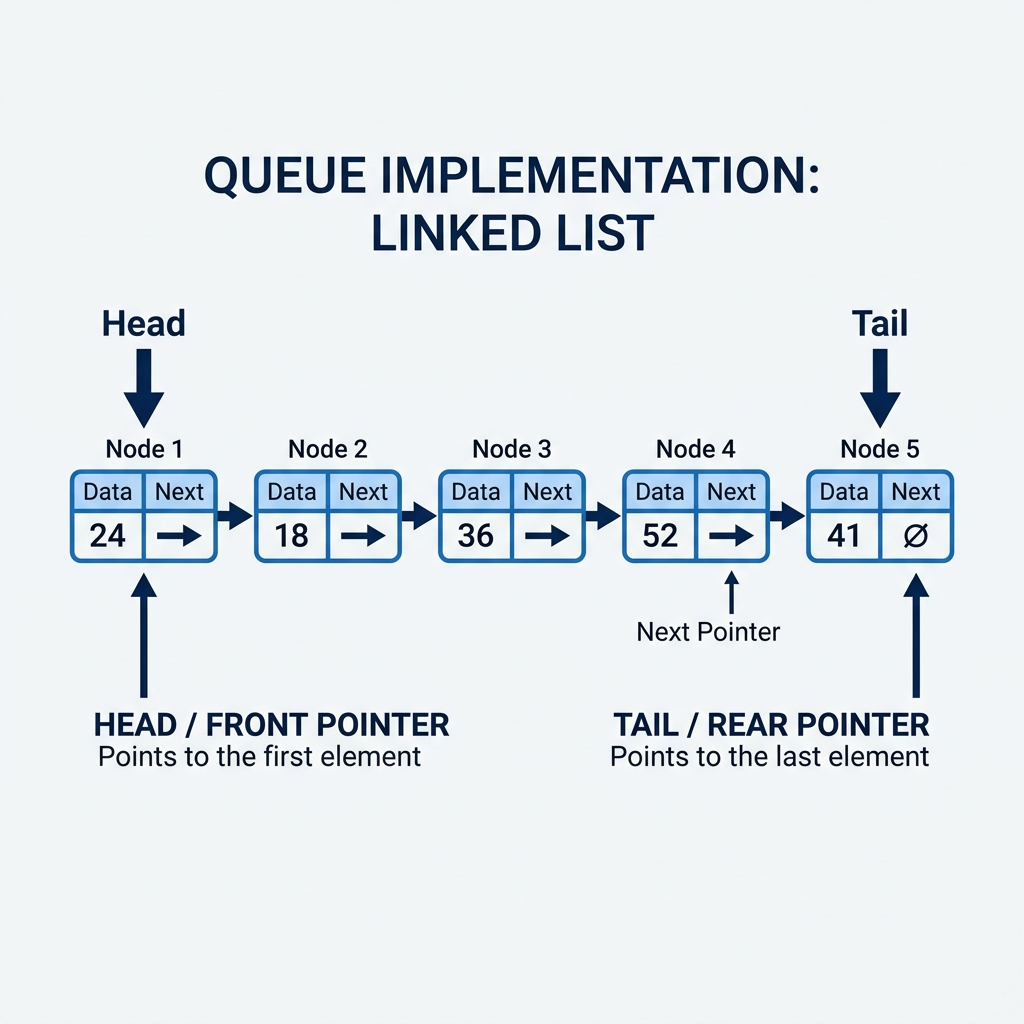<br>
  <em>Figura 1: Representación de una Cola implementada con Nodos. El puntero <code>tail</code> permite inserciones rápidas.</em>
</p>

*   **Enqueue (Encolar):** Se realiza siempre por la parte trasera (`tail`). Enlazamos el nuevo nodo después de `tail` y movemos `tail` para que apunte al nuevo nodo.
*   **Dequeue (Desencolar):** Se realiza siempre por el frente (`head`). Guardamos los datos de `head`, movemos `head` a `head.next` y liberamos el nodo anterior.

In [1]:
%%writefile LinkedQueue.java
public class LinkedQueue {

    private class Node {
        int data;
        Node next;
        public Node(int data) { this.data = data; }
    }

    private Node head, tail;

    public LinkedQueue() {
        this.head = this.tail = null;
    }

    public void enqueue(int key) {
        Node newNode = new Node(key);
        // Si la cola está vacía, el nuevo nodo es tanto el head como el tail
        if (this.tail == null) {
            this.head = this.tail = newNode;
            return;
        }
        // Lo añadimos al final y movemos el tail
        this.tail.next = newNode;
        this.tail = newNode;
    }

    public int dequeue() {
        if (this.head == null) {
            System.out.println("Cola vacía.");
            return -1;
        }
        int removedData = this.head.data;
        this.head = this.head.next; // Avanzamos el head

        // Si el head se vuelve null, la cola se vació por completo (tail también es null)
        if (this.head == null) {
            this.tail = null;
        }
        return removedData;
    }

    public static void main(String[] args) {
        LinkedQueue queue = new LinkedQueue();
        queue.enqueue(10);
        queue.enqueue(20);
        System.out.println("Desencolado: " + queue.dequeue()); // 10
        queue.enqueue(30);
        System.out.println("Desencolado: " + queue.dequeue()); // 20
    }
}


Writing LinkedQueue.java


In [2]:
!javac LinkedQueue.java
!java LinkedQueue

[0.031s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.032s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Desencolado: 10
Desencolado: 20


## 2. Listas Doblemente Enlazadas (Doubly Linked Lists)

La principal limitación de una lista enlazada simple es que solo puede recorrerse en una dirección (hacia adelante). Si estamos en un nodo, no podemos saber cuál es el nodo anterior.

Una **Lista Doblemente Enlazada** soluciona esto añadiendo un nuevo puntero a la estructura del nodo: el puntero `prev` (previo).

<p align="center">
  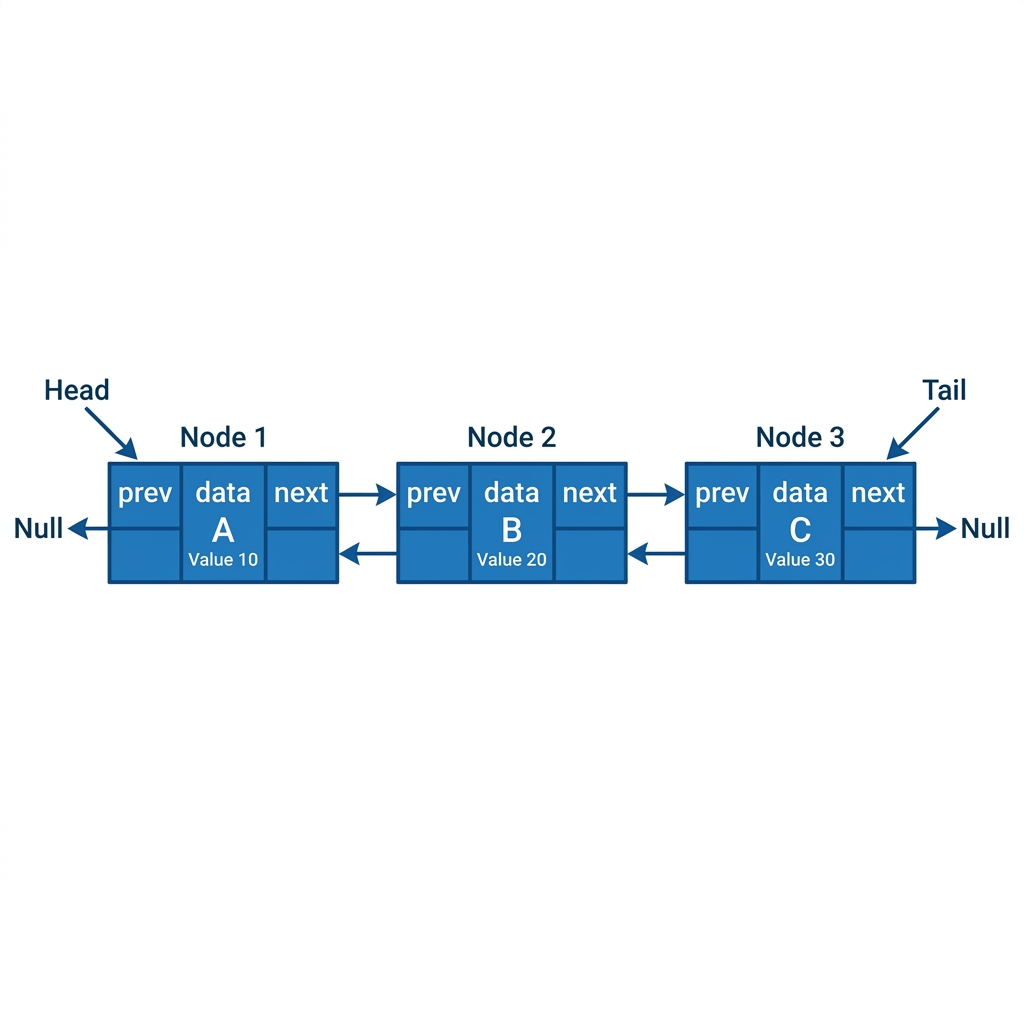<br>
  <em>Figura 2: Cada nodo apunta al siguiente (`next`) y al anterior (`prev`).</em>
</p>

### Ventajas
1. Permite navegar hacia adelante y hacia atrás.
2. La operación de **eliminar un nodo específico** es mucho más sencilla en $O(1)$ si ya tenemos la referencia al nodo, porque no necesitamos recorrer la lista desde el `head` para descubrir quién era su antecesor.

In [3]:
%%writefile DoublyLinkedList.java
public class DoublyLinkedList {

    class Node {
        int data;
        Node prev;
        Node next;

        public Node(int data) { this.data = data; }
    }

    Node head, tail;

    public void insertFront(int data) {
        Node newNode = new Node(data);
        if (head == null) {
            head = tail = newNode;
            return;
        }
        // Conexión bidireccional
        head.prev = newNode;
        newNode.next = head;
        head = newNode;
    }

    public void printForward() {
        Node current = head;
        System.out.print("Adelante: ");
        while (current != null) {
            System.out.print(current.data + " ");
            current = current.next;
        }
        System.out.println();
    }

    public void printBackward() {
        Node current = tail;
        System.out.print("Atrás: ");
        while (current != null) {
            System.out.print(current.data + " ");
            current = current.prev; // ¡Retrocedemos!
        }
        System.out.println();
    }

    public static void main(String[] args) {
        DoublyLinkedList dll = new DoublyLinkedList();
        dll.insertFront(10);
        dll.insertFront(20);
        dll.insertFront(30);

        dll.printForward();
        dll.printBackward();
    }
}


Writing DoublyLinkedList.java


In [4]:
!javac DoublyLinkedList.java
!java DoublyLinkedList

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Adelante: 30 20 10 
Atrás: 10 20 30 


> **🔗 Recurso Recomendado:** Para ver las animaciones bidireccionales en acción durante operaciones complejas como eliminar en el centro, pruebe el módulo de Doubly Linked List en [VisuAlgo](https://visualgo.net/en/list).

### 2.1 Colas de Doble Extremo (Deques)
El hijo perfecto de una Cola (Queue) y una Lista Doblemente Enlazada (Doubly Linked List) es el **Deque** (Double-Ended Queue, pronunciado "deck").

En un Deque, a diferencia de una cola normal, puedes insertar **Y** eliminar elementos por **ambos extremos** (por el frente o por detrás) en tiempo constante $O(1)$.

<p align="center">
  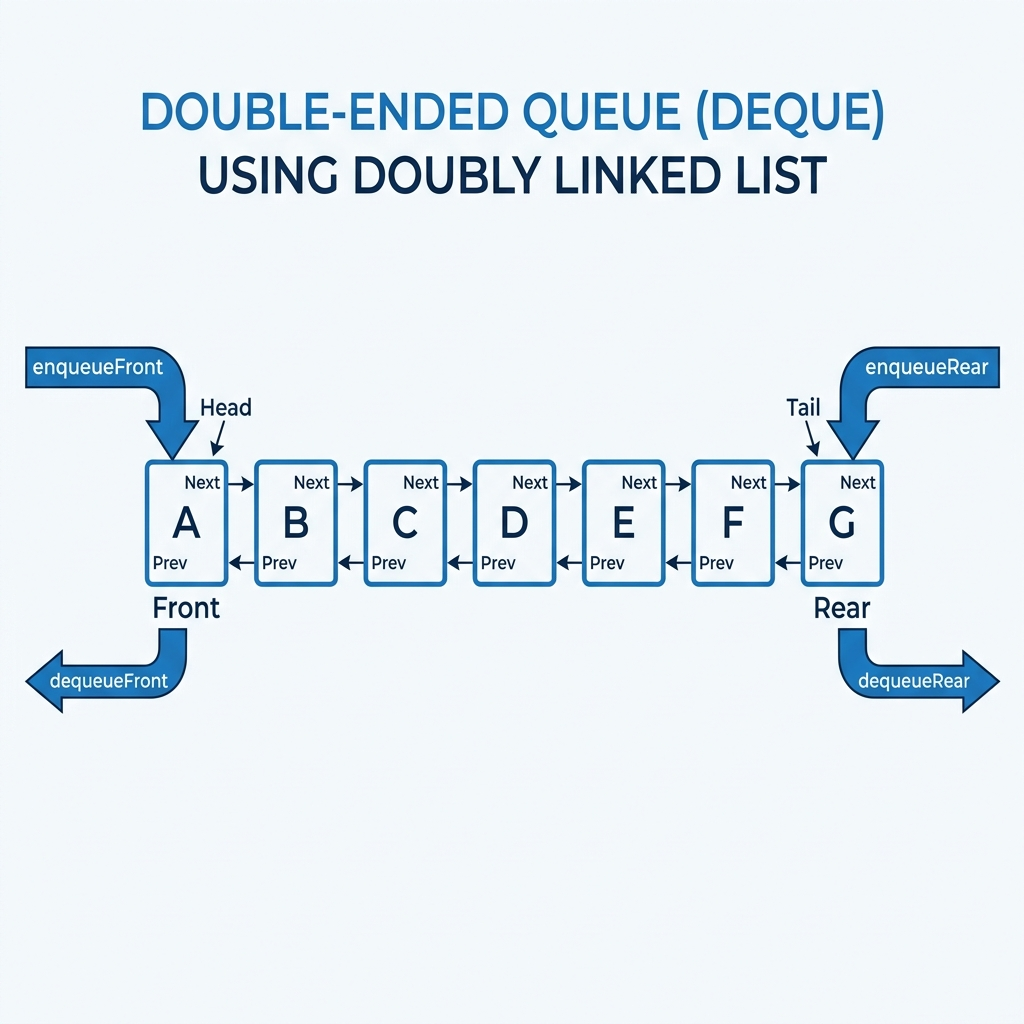<br>
  <em>Figura 4: En un Deque puedes hacer enqueue y dequeue tanto en 'head' como en 'tail' gracias a los punteros dobles.</em>
</p>

In [5]:
%%writefile DequeExample.java
import java.util.Deque;
import java.util.LinkedList;

public class DequeExample {
    public static void main(String[] args) {
        // Java ya tiene una interfaz Deque, y LinkedList la implementa!
        Deque<String> deque = new LinkedList<>();

        deque.addFirst("Inicio");
        deque.addLast("Final");
        deque.addFirst("Súper Inicio");

        System.out.println("Estado del Deque: " + deque);

        System.out.println("Saco del frente: " + deque.removeFirst());
        System.out.println("Saco del final: " + deque.removeLast());
    }
}


Writing DequeExample.java


In [6]:
!javac DequeExample.java
!java DequeExample

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Estado del Deque: [Súper Inicio, Inicio, Final]
Saco del frente: Súper Inicio
Saco del final: Final


### 2.2 Costo de Memoria (Overhead) en Nodos Dobles
Como ingenieros, debemos entender los "trade-offs" (compensaciones). Hemos visto que las listas doblemente enlazadas son maravillosas porque permiten recorridos bidireccionales y eliminación en $O(1)$.

**¿Cuál es el precio a pagar? La Memoria.**

En una lista simple, cada nodo almacena: `[ Dato | Next ]`. En Java, en una arquitectura de 64 bits, una referencia (`Next`) pesa usualmente **8 bytes**.
En una lista doble, cada nodo almacena: `[ Prev | Dato | Next ]`. Hemos añadido otro puntero que también pesa **8 bytes**.

Si tenemos una lista con **1 millón de elementos**, usar una Lista Doblemente Enlazada consumirá **8 MB extras de memoria RAM** en comparación a una Lista Enlazada Simple, ¡solo para guardar las flechas de regreso! Si el dispositivo tiene poca memoria, a veces es mejor iterar (sacrificar CPU) usando listas simples, que sacrificar RAM usando listas dobles.

## 3. Listas Enlazadas Circulares (Circular Linked Lists)
En la clase anterior vimos los Arreglos Circulares usando aritmética modular (`%`). En las Listas Enlazadas, hacer que la lista sea circular es mucho más sencillo y no requiere matemáticas complejas.

Una **Lista Enlazada Circular** es simplemente una lista estándar (simple o doble) donde el último nodo (`tail`) **no apunta a `null`**, sino que su puntero `next` apunta de regreso al `head`.

Esto forma un anillo continuo de memoria. Es sumamente utilizado en Sistemas Operativos para asignar tiempos de procesamiento a diferentes programas de forma cíclica (algoritmo Round-Robin).

In [7]:
%%writefile CircularLinkedList.java
public class CircularLinkedList {
    class Node {
        int data;
        Node next;
        public Node(int data) { this.data = data; }
    }

    private Node head = null;
    private Node tail = null;

    public void insert(int data) {
        Node newNode = new Node(data);
        if (head == null) {
            head = newNode;
            tail = newNode;
            newNode.next = head; // Se apunta a sí mismo
        } else {
            tail.next = newNode;
            tail = newNode;
            tail.next = head; // Cerramos el círculo
        }
    }

    public void printList() {
        if (head == null) return;

        Node current = head;
        System.out.print("Recorrido Circular: ");

        // Usamos do-while para garantizar que entremos la primera vez
        // y nos detenemos cuando volvamos a dar la vuelta completa (current == head)
        do {
            System.out.print(current.data + " -> ");
            current = current.next;
        } while (current != head);

        System.out.println("(Vuelve al inicio: " + head.data + ")");
    }

    public static void main(String[] args) {
        CircularLinkedList cll = new CircularLinkedList();
        cll.insert(1);
        cll.insert(2);
        cll.insert(3);
        cll.printList();
    }
}


Writing CircularLinkedList.java


In [8]:
!javac CircularLinkedList.java
!java CircularLinkedList

[0.003s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.003s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Recorrido Circular: 1 -> 2 -> 3 -> (Vuelve al inicio: 1)


## 4. Múltiples Pilas en un Solo Arreglo (Capacidad Fija)

### 4.1 Implementación Clásica: Dos Pilas (Two Stacks)

Un problema clásico de optimización de memoria (muy común en entrevistas técnicas) es implementar **dos pilas (stacks) compartiendo el mismo arreglo estático**, asegurándose de que una pila no falle a menos que literalmente no quede espacio libre en todo el arreglo.

La forma más eficiente en espacio de hacerlo es anclar la primera pila en el inicio del arreglo (`índice 0`) y hacer que crezca hacia la derecha, mientras que la segunda pila se ancla en el final (`índice N-1`) y crece hacia la izquierda.

<p align="center">
  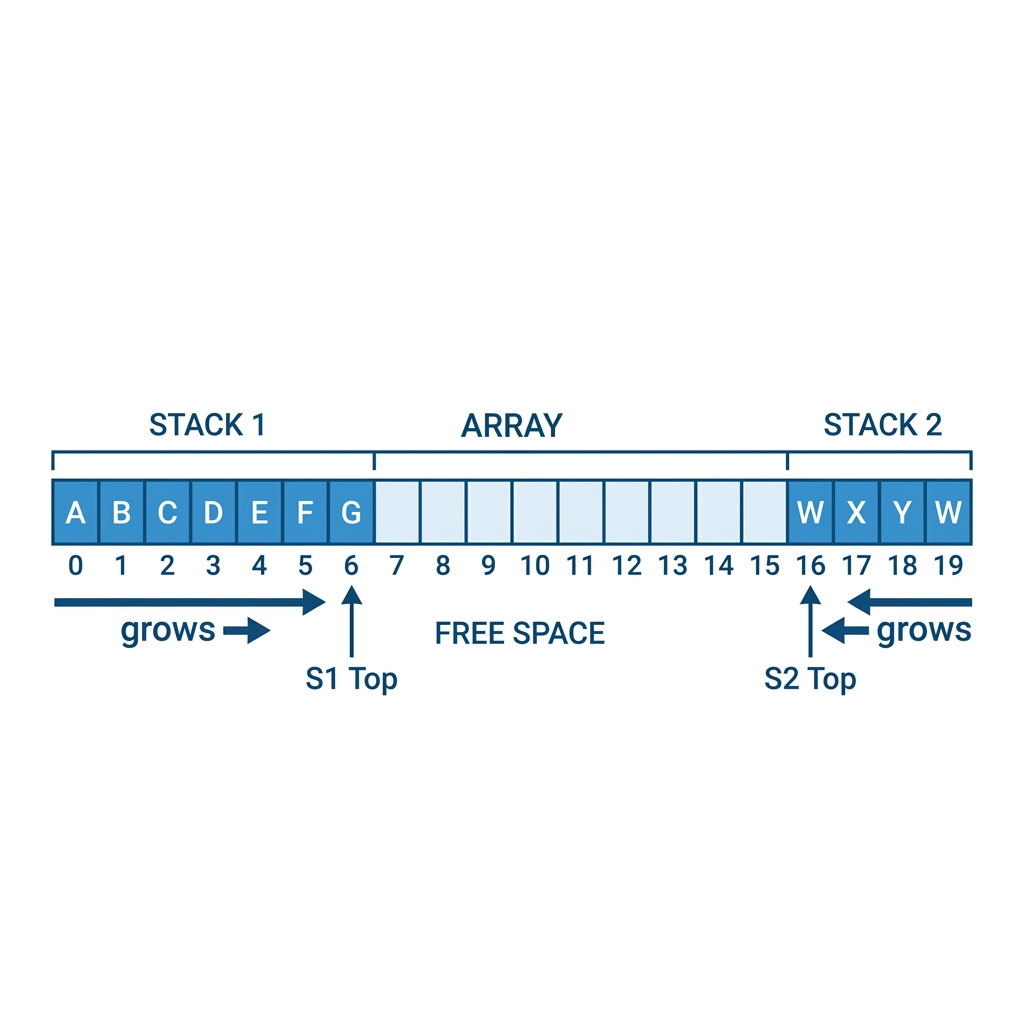<br>
  <em>Figura 3: Representación de Dos Pilas compartiendo eficientemente un solo arreglo.</em>
</p>

In [9]:
%%writefile TwoStacks.java
public class TwoStacks {
    private int[] array;
    private int top1;
    private int top2;
    private int capacity;

    public TwoStacks(int n) {
        this.capacity = n;
        this.array = new int[n];
        this.top1 = -1;       // Pila 1 inicia "fuera" por la izquierda
        this.top2 = n;        // Pila 2 inicia "fuera" por la derecha
    }

    // Insertar en la Pila 1
    public void push1(int x) {
        // Hay espacio si hay al menos un espacio vacío entre top1 y top2
        if (top1 < top2 - 1) {
            top1++;
            array[top1] = x;
        } else {
            System.out.println("Stack Overflow en Pila 1");
        }
    }

    // Insertar en la Pila 2
    public void push2(int x) {
        if (top1 < top2 - 1) {
            top2--;
            array[top2] = x;
        } else {
            System.out.println("Stack Overflow en Pila 2");
        }
    }

    public int pop1() {
        if (top1 >= 0) {
            int x = array[top1];
            top1--;
            return x;
        }
        System.out.println("Stack Underflow en Pila 1");
        return -1;
    }

    public int pop2() {
        if (top2 < capacity) {
            int x = array[top2];
            top2++;
            return x;
        }
        System.out.println("Stack Underflow en Pila 2");
        return -1;
    }

    public static void main(String[] args) {
        TwoStacks ts = new TwoStacks(5); // Arreglo de tamaño 5
        ts.push1(5);
        ts.push2(10);
        ts.push2(15);
        ts.push1(11);
        ts.push2(7);

        System.out.println("Pop Pila 1: " + ts.pop1()); // 11
        ts.push2(40); // El espacio liberado por la pila 1 lo puede usar la pila 2
        System.out.println("Pop Pila 2: " + ts.pop2()); // 40
    }
}


Writing TwoStacks.java


In [10]:
!javac TwoStacks.java
!java TwoStacks

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Pop Pila 1: 11
Pop Pila 2: 40


### 4.2 Extensión Teórica: $K$ Pilas en un Arreglo

¿Qué pasaría si la necesidad del sistema operativo exige alojar **3, 4 o $K$ pilas diferentes** dentro de ese mismo bloque de memoria?

El algoritmo de "extremos hacia el centro" solo funciona para $K=2$. Si $K > 2$, la "Alternativa" más eficiente utiliza arreglos auxiliares:
1.  **Arreglo `top[]`**: Guarda el índice superior actual de cada una de las $K$ pilas.
2.  **Arreglo `next[]`**: Cumple un doble propósito:
    *   Mantiene registro del siguiente espacio libre disponible (Free List).
    *   Guarda el puntero al elemento previo de la pila actual (comportándose como los punteros `next` en una lista enlazada, ¡pero dentro de un arreglo estático!).

Este enfoque avanzado garantiza inserciones y eliminaciones en $O(1)$ sin importar cuántas pilas coexistan, aprovechando los espacios liberados aleatoriamente.

---
## 5. Bibliografía
- Streib, J. T. (2014). *Guide to Data Structures: A Concise Introduction Using Java*. Springer. (Capítulo 7: Doubly Linked Lists).